# Chapter 10.1: RecSys Serving Architecture

## Learning Objectives

By the end of this notebook, you will be able to:

1. Design a **microservice architecture** for recommendation serving with retrieval, ranking, and feature services
2. Understand **latency budgets** and how to allocate time across pipeline stages (50ms retrieval, 20ms ranking, 10ms re-ranking)
3. Implement **caching strategies** for user embeddings, item embeddings, and result caches
4. Compare **async vs sync** serving patterns and choose the right one for each use case
5. Apply **service mesh** and load balancing concepts to recommendation services
6. Build and simulate a **multi-stage serving pipeline** with latency tracking
7. Identify **bottlenecks** in production serving systems and apply mitigation strategies

## Prerequisites

- Understanding of recommendation system fundamentals (retrieval + ranking)
- Basic knowledge of distributed systems concepts
- Python proficiency including async/await patterns

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.1_serving_arch.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.1_serving_arch.ipynb)

In [1]:
import numpy as np
import time
import random
import json
import asyncio
import threading
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any
from collections import OrderedDict, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Microservice Architecture for Recommendation Systems

Modern production recommendation systems decompose the serving pipeline into **independent microservices**. This architecture, adopted by Meta, Google, ByteDance, and others, provides:

- **Independent scaling**: Retrieval needs many replicas for throughput; ranking needs GPU for compute
- **Independent deployment**: Update the ranking model without touching retrieval
- **Fault isolation**: A ranking service failure doesn't crash the entire system

The canonical pipeline looks like:

$$
\text{Request} \rightarrow \text{Feature Service} \rightarrow \text{Retrieval Service} \rightarrow \text{Ranking Service} \rightarrow \text{Re-ranking Service} \rightarrow \text{Response}
$$

Each service has a **latency budget** allocated from the total end-to-end budget (typically 100-200ms):

| Stage | Typical Budget | Items Processed | Key Resource |
|-------|---------------|-----------------|-------------|
| Feature Lookup | 10-20ms | - | Memory/Cache |
| Retrieval | 30-50ms | Millions → 1000s | CPU/ANN Index |
| Ranking | 15-30ms | 1000s → 100s | GPU |
| Re-ranking | 5-10ms | 100s → 10s | CPU |

> **💡 Concept:** The funnel narrows at each stage. Retrieval scans millions cheaply (ANN), ranking scores thousands precisely (deep model), and re-ranking applies business logic to the final slate.

In [2]:
# Simulate a microservice architecture for recommendation serving

@dataclass
class ServiceConfig:
    name: str
    mean_latency_ms: float
    std_latency_ms: float
    timeout_ms: float
    max_items_in: int
    max_items_out: int


@dataclass
class ServiceResponse:
    service_name: str
    latency_ms: float
    num_items: int
    success: bool
    error: Optional[str] = None


class RecService:
    """Simulates a single microservice in the rec pipeline."""

    def __init__(self, config: ServiceConfig):
        self.config = config
        self.call_count = 0
        self.total_latency = 0.0

    def serve(self, num_items_in: int) -> ServiceResponse:
        self.call_count += 1
        # Simulate latency (log-normal distribution, realistic for network calls)
        latency = np.random.lognormal(
            mean=np.log(self.config.mean_latency_ms),
            sigma=self.config.std_latency_ms / self.config.mean_latency_ms
        )
        self.total_latency += latency

        if latency > self.config.timeout_ms:
            return ServiceResponse(
                service_name=self.config.name,
                latency_ms=self.config.timeout_ms,
                num_items=0,
                success=False,
                error="Timeout"
            )

        # Items are filtered/ranked down
        items_in = min(num_items_in, self.config.max_items_in)
        items_out = min(items_in, self.config.max_items_out)

        return ServiceResponse(
            service_name=self.config.name,
            latency_ms=latency,
            num_items=items_out,
            success=True
        )


# Define the pipeline services
services = {
    "feature_service": RecService(ServiceConfig(
        name="Feature Service", mean_latency_ms=8, std_latency_ms=3,
        timeout_ms=20, max_items_in=1, max_items_out=1
    )),
    "retrieval": RecService(ServiceConfig(
        name="Retrieval Service", mean_latency_ms=35, std_latency_ms=10,
        timeout_ms=80, max_items_in=1_000_000, max_items_out=1000
    )),
    "ranking": RecService(ServiceConfig(
        name="Ranking Service", mean_latency_ms=18, std_latency_ms=5,
        timeout_ms=40, max_items_in=1000, max_items_out=100
    )),
    "reranking": RecService(ServiceConfig(
        name="Re-ranking Service", mean_latency_ms=5, std_latency_ms=2,
        timeout_ms=15, max_items_in=100, max_items_out=20
    )),
}

print("Pipeline services configured:")
for name, svc in services.items():
    print(f"  {svc.config.name}: {svc.config.mean_latency_ms}ms mean, "
          f"{svc.config.timeout_ms}ms timeout")

Pipeline services configured:
  Feature Service: 8ms mean, 20ms timeout
  Retrieval Service: 35ms mean, 80ms timeout
  Ranking Service: 18ms mean, 40ms timeout
  Re-ranking Service: 5ms mean, 15ms timeout


In [3]:
def run_pipeline(services: Dict[str, RecService], num_requests: int = 1000) -> List[Dict]:
    """Run the full rec pipeline for multiple requests."""
    results = []
    catalog_size = 500_000

    for i in range(num_requests):
        request_log = {"request_id": i, "stages": [], "total_latency_ms": 0, "success": True}
        current_items = catalog_size

        for stage_name in ["feature_service", "retrieval", "ranking", "reranking"]:
            svc = services[stage_name]
            response = svc.serve(current_items)
            request_log["stages"].append({
                "name": response.service_name,
                "latency_ms": response.latency_ms,
                "items_out": response.num_items,
                "success": response.success
            })
            request_log["total_latency_ms"] += response.latency_ms

            if not response.success:
                request_log["success"] = False
                break
            current_items = response.num_items

        results.append(request_log)

    return results


# Run simulation
np.random.seed(42)
results = run_pipeline(services, num_requests=5000)

# Analyze results
total_latencies = [r["total_latency_ms"] for r in results if r["success"]]
success_rate = sum(1 for r in results if r["success"]) / len(results)

print(f"Success rate: {success_rate:.2%}")
print(f"Latency P50: {np.percentile(total_latencies, 50):.1f}ms")
print(f"Latency P90: {np.percentile(total_latencies, 90):.1f}ms")
print(f"Latency P99: {np.percentile(total_latencies, 99):.1f}ms")
print(f"Latency P99.9: {np.percentile(total_latencies, 99.9):.1f}ms")

Success rate: 98.54%
Latency P50: 67.7ms
Latency P90: 84.9ms
Latency P99: 101.6ms
Latency P99.9: 112.8ms


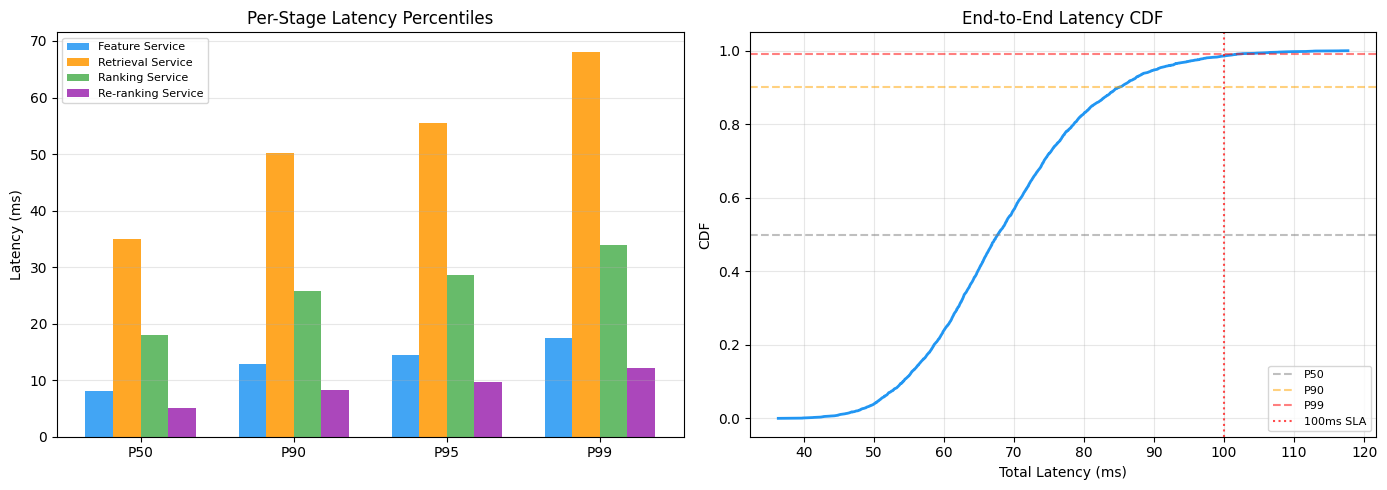

In [4]:
# Visualize latency distribution by stage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Latency distribution per stage (stacked)
stage_names = ["Feature Service", "Retrieval Service", "Ranking Service", "Re-ranking Service"]
stage_latencies = {name: [] for name in stage_names}

for r in results:
    if r["success"]:
        for stage in r["stages"]:
            stage_latencies[stage["name"]].append(stage["latency_ms"])

colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
bottoms = np.zeros(len(total_latencies))

# Show percentiles as bar chart
percentiles = [50, 90, 95, 99]
x = np.arange(len(percentiles))
width = 0.18

for i, name in enumerate(stage_names):
    vals = [np.percentile(stage_latencies[name], p) for p in percentiles]
    axes[0].bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels([f"P{p}" for p in percentiles])
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Per-Stage Latency Percentiles")
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Right: Total end-to-end latency CDF
sorted_lat = np.sort(total_latencies)
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
axes[1].plot(sorted_lat, cdf, linewidth=2, color='#2196F3')
axes[1].axhline(y=0.50, color='gray', linestyle='--', alpha=0.5, label='P50')
axes[1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.5, label='P90')
axes[1].axhline(y=0.99, color='red', linestyle='--', alpha=0.5, label='P99')
axes[1].axvline(x=100, color='red', linestyle=':', alpha=0.7, label='100ms SLA')
axes[1].set_xlabel("Total Latency (ms)")
axes[1].set_ylabel("CDF")
axes[1].set_title("End-to-End Latency CDF")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Caching Strategies

Caching is **critical** for meeting latency SLAs. In production rec systems, there are three main caching layers:

1. **User Embedding Cache**: Stores pre-computed user embeddings. Hit rate typically 90%+ since active users are a small fraction of total.
2. **Item Embedding Cache**: Stores item embeddings for ranking. Near 100% hit rate since the item catalog changes slowly.
3. **Result Cache**: Stores full recommendation results for recently seen (user, context) pairs. Hit rate varies 10-50%.

Cache invalidation strategies:
- **TTL-based**: Embeddings expire after a fixed time (e.g., 1 hour for users, 24 hours for items)
- **Event-driven**: Invalidate user cache on new interaction, item cache on catalog update
- **Hybrid**: TTL + event-driven for correctness with bounded staleness

$$
\text{Effective Latency} = (1 - h) \cdot L_{\text{compute}} + h \cdot L_{\text{cache}}
$$

where $h$ is hit rate, $L_{\text{compute}}$ is compute latency, $L_{\text{cache}}$ is cache access latency.

> **⚠️ Common Pitfall:** Result-level caching can degrade recommendation freshness. If a user interacts with an item and sees the same cached recommendations, it feels broken. Always invalidate on user actions.

In [5]:
class LRUCache:
    """Thread-safe LRU cache with TTL support."""

    def __init__(self, capacity: int, ttl_seconds: float = 3600.0):
        self.capacity = capacity
        self.ttl_seconds = ttl_seconds
        self.cache: OrderedDict = OrderedDict()
        self.timestamps: Dict[str, float] = {}
        self.hits = 0
        self.misses = 0

    def get(self, key: str, current_time: float) -> Optional[Any]:
        if key in self.cache:
            # Check TTL
            if current_time - self.timestamps[key] > self.ttl_seconds:
                # Expired
                del self.cache[key]
                del self.timestamps[key]
                self.misses += 1
                return None
            # Move to end (most recently used)
            self.cache.move_to_end(key)
            self.hits += 1
            return self.cache[key]
        self.misses += 1
        return None

    def put(self, key: str, value: Any, current_time: float):
        if key in self.cache:
            self.cache.move_to_end(key)
        self.cache[key] = value
        self.timestamps[key] = current_time
        if len(self.cache) > self.capacity:
            oldest_key, _ = self.cache.popitem(last=False)
            del self.timestamps[oldest_key]

    @property
    def hit_rate(self) -> float:
        total = self.hits + self.misses
        return self.hits / total if total > 0 else 0.0


class CachedRecPipeline:
    """Rec pipeline with multi-level caching."""

    def __init__(self):
        self.user_embedding_cache = LRUCache(capacity=10000, ttl_seconds=3600)
        self.item_embedding_cache = LRUCache(capacity=50000, ttl_seconds=86400)
        self.result_cache = LRUCache(capacity=5000, ttl_seconds=300)

        # Simulated compute costs (ms)
        self.user_embed_compute_ms = 5.0
        self.item_embed_compute_ms = 0.1  # per item
        self.ranking_compute_ms = 15.0
        self.cache_lookup_ms = 0.1

    def serve(self, user_id: str, context: str, num_candidates: int,
              current_time: float) -> Dict:
        latency = 0.0
        cache_hits = []

        # Check result cache first
        result_key = f"{user_id}:{context}"
        latency += self.cache_lookup_ms
        cached_result = self.result_cache.get(result_key, current_time)
        if cached_result is not None:
            cache_hits.append("result")
            return {"latency_ms": latency, "cache_hits": cache_hits, "source": "result_cache"}

        # User embedding lookup
        latency += self.cache_lookup_ms
        user_emb = self.user_embedding_cache.get(user_id, current_time)
        if user_emb is not None:
            cache_hits.append("user_embedding")
        else:
            latency += self.user_embed_compute_ms
            user_emb = np.random.randn(64)  # Simulate computation
            self.user_embedding_cache.put(user_id, user_emb, current_time)

        # Item embedding lookups
        items_from_cache = 0
        for i in range(num_candidates):
            item_key = f"item_{i % 1000}"  # Simulate repeated items
            latency += self.cache_lookup_ms
            item_emb = self.item_embedding_cache.get(item_key, current_time)
            if item_emb is not None:
                items_from_cache += 1
            else:
                latency += self.item_embed_compute_ms
                item_emb = np.random.randn(64)
                self.item_embedding_cache.put(item_key, item_emb, current_time)

        if items_from_cache > 0:
            cache_hits.append(f"item_embeddings({items_from_cache}/{num_candidates})")

        # Ranking
        latency += self.ranking_compute_ms

        # Store in result cache
        self.result_cache.put(result_key, "result_placeholder", current_time)

        return {"latency_ms": latency, "cache_hits": cache_hits, "source": "computed"}


# Simulate traffic with caching
np.random.seed(42)
pipeline = CachedRecPipeline()

# Simulate power-law user activity (some users are much more active)
num_users = 5000
user_activity = np.random.pareto(1.5, num_users)
user_activity = user_activity / user_activity.sum()

latencies_with_cache = []
latencies_cold = []
current_time = 0.0

for req_idx in range(10000):
    user_idx = np.random.choice(num_users, p=user_activity)
    user_id = f"user_{user_idx}"
    context = f"ctx_{req_idx % 10}"  # 10 different contexts
    current_time += 0.01  # 10ms between requests

    result = pipeline.serve(user_id, context, num_candidates=200, current_time=current_time)
    latencies_with_cache.append(result["latency_ms"])

print(f"User Embedding Cache hit rate: {pipeline.user_embedding_cache.hit_rate:.2%}")
print(f"Item Embedding Cache hit rate: {pipeline.item_embedding_cache.hit_rate:.2%}")
print(f"Result Cache hit rate: {pipeline.result_cache.hit_rate:.2%}")
print(f"\nLatency with caching - P50: {np.percentile(latencies_with_cache, 50):.1f}ms")
print(f"Latency with caching - P99: {np.percentile(latencies_with_cache, 99):.1f}ms")

User Embedding Cache hit rate: 61.31%
Item Embedding Cache hit rate: 99.98%
Result Cache hit rate: 34.64%

Latency with caching - P50: 35.2ms
Latency with caching - P99: 40.2ms


## 3. Async vs Sync Serving Patterns

In production rec systems, the serving pattern depends on the **dependency graph** between services:

**Synchronous (Sequential)**:
- Feature lookup → Retrieval → Ranking → Re-ranking
- Total latency = sum of all stages
- Simple to implement and debug

**Asynchronous (Parallel)**:
- Multiple retrieval sources queried in parallel (e.g., collaborative filtering + content-based + trending)
- Feature lookup runs in parallel with retrieval
- Total latency = max(parallel stages) + sequential stages

$$
L_{\text{async}} = L_{\text{feature}} + \max(L_{\text{retrieval\_1}}, L_{\text{retrieval\_2}}, ..., L_{\text{retrieval\_k}}) + L_{\text{ranking}} + L_{\text{reranking}}
$$

vs.

$$
L_{\text{sync}} = L_{\text{feature}} + \sum_{i=1}^{k} L_{\text{retrieval\_i}} + L_{\text{ranking}} + L_{\text{reranking}}
$$

> **🔑 Pro Tip:** Meta's feed ranking uses a "scatter-gather" pattern: the orchestrator fans out to multiple retrieval services in parallel, waits for all (with timeout), merges results, then calls ranking sequentially.

In [6]:
# Simulate sync vs async serving with multiple retrieval sources

def simulate_service_latency(mean_ms: float, std_ms: float) -> float:
    """Simulate realistic service latency with log-normal distribution."""
    return np.random.lognormal(
        mean=np.log(mean_ms), sigma=std_ms / mean_ms
    )


def sync_pipeline(num_retrieval_sources: int = 3) -> float:
    """Sequential pipeline: all services called one after another."""
    total = 0.0
    # Feature service
    total += simulate_service_latency(8, 3)
    # Retrieval sources (sequential)
    for _ in range(num_retrieval_sources):
        total += simulate_service_latency(30, 8)
    # Ranking
    total += simulate_service_latency(18, 5)
    # Re-ranking
    total += simulate_service_latency(5, 2)
    return total


def async_pipeline(num_retrieval_sources: int = 3) -> float:
    """Parallel pipeline: retrieval sources queried in parallel."""
    total = 0.0
    # Feature service (can overlap with retrieval in some designs)
    feature_latency = simulate_service_latency(8, 3)
    # Retrieval sources (parallel - take max)
    retrieval_latencies = [simulate_service_latency(30, 8)
                           for _ in range(num_retrieval_sources)]
    # Feature and retrieval run in parallel
    total += max(feature_latency, max(retrieval_latencies))
    # Ranking (sequential, needs retrieval results)
    total += simulate_service_latency(18, 5)
    # Re-ranking
    total += simulate_service_latency(5, 2)
    return total


# Simulate both patterns
np.random.seed(42)
n_requests = 5000

sync_latencies = [sync_pipeline(3) for _ in range(n_requests)]
async_latencies = [async_pipeline(3) for _ in range(n_requests)]

print("Sync Pipeline (3 retrieval sources):")
print(f"  P50: {np.percentile(sync_latencies, 50):.1f}ms")
print(f"  P90: {np.percentile(sync_latencies, 90):.1f}ms")
print(f"  P99: {np.percentile(sync_latencies, 99):.1f}ms")

print(f"\nAsync Pipeline (3 retrieval sources):")
print(f"  P50: {np.percentile(async_latencies, 50):.1f}ms")
print(f"  P90: {np.percentile(async_latencies, 90):.1f}ms")
print(f"  P99: {np.percentile(async_latencies, 99):.1f}ms")

improvement = (1 - np.mean(async_latencies) / np.mean(sync_latencies)) * 100
print(f"\nAsync reduces mean latency by {improvement:.1f}%")

Sync Pipeline (3 retrieval sources):
  P50: 124.7ms
  P90: 146.9ms
  P99: 167.3ms

Async Pipeline (3 retrieval sources):
  P50: 61.6ms
  P90: 75.5ms
  P99: 89.7ms

Async reduces mean latency by 50.3%


## 4. Service Mesh and Load Balancing

Production rec systems use **service meshes** (e.g., Envoy, Istio) for:

- **Load balancing**: Distribute requests across service replicas
- **Circuit breaking**: Stop sending to unhealthy replicas
- **Retry budgets**: Retry failed requests within latency budget
- **Rate limiting**: Protect downstream services from overload

Common load balancing strategies for rec:

| Strategy | Description | Best For |
|----------|-------------|----------|
| Round Robin | Equal distribution | Homogeneous replicas |
| Least Connections | Route to least busy | Heterogeneous load |
| Weighted | Route based on replica capacity | Mixed hardware (CPU/GPU) |
| Consistent Hashing | Same user → same replica | Stateful caches |

> **💡 Concept:** Consistent hashing is especially important for rec systems because it ensures the same user's requests hit the same server, maximizing cache hit rate for user embeddings.

In [7]:
# Simulate different load balancing strategies

class ServiceReplica:
    def __init__(self, replica_id: int, capacity_factor: float = 1.0):
        self.replica_id = replica_id
        self.capacity_factor = capacity_factor
        self.active_connections = 0
        self.total_requests = 0
        self.cache = LRUCache(capacity=500, ttl_seconds=3600)

    def process(self, user_id: str, current_time: float) -> float:
        self.active_connections += 1
        self.total_requests += 1

        # Check local cache
        cached = self.cache.get(user_id, current_time)
        if cached is not None:
            base_latency = 2.0  # Cache hit
        else:
            base_latency = 20.0  # Cache miss, full computation
            self.cache.put(user_id, True, current_time)

        # Latency increases with load
        load_factor = 1.0 + 0.1 * self.active_connections / self.capacity_factor
        latency = base_latency * load_factor

        self.active_connections -= 1
        return latency


def consistent_hash(user_id: str, num_replicas: int) -> int:
    """Simple consistent hashing."""
    return hash(user_id) % num_replicas


def simulate_load_balancing(strategy: str, num_replicas: int = 5,
                            num_requests: int = 5000) -> Dict:
    replicas = [ServiceReplica(i) for i in range(num_replicas)]
    rr_counter = 0

    # Power-law user distribution
    num_users = 1000
    user_probs = np.random.pareto(1.5, num_users)
    user_probs /= user_probs.sum()

    latencies = []
    current_time = 0.0

    for req_idx in range(num_requests):
        user_idx = np.random.choice(num_users, p=user_probs)
        user_id = f"user_{user_idx}"
        current_time += 0.001

        if strategy == "round_robin":
            replica_idx = rr_counter % num_replicas
            rr_counter += 1
        elif strategy == "random":
            replica_idx = random.randint(0, num_replicas - 1)
        elif strategy == "least_connections":
            replica_idx = min(range(num_replicas),
                              key=lambda i: replicas[i].active_connections)
        elif strategy == "consistent_hash":
            replica_idx = consistent_hash(user_id, num_replicas)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        latency = replicas[replica_idx].process(user_id, current_time)
        latencies.append(latency)

    # Compute cache hit rates per replica
    cache_hit_rates = [r.cache.hit_rate for r in replicas]
    request_distribution = [r.total_requests for r in replicas]

    return {
        "strategy": strategy,
        "latencies": latencies,
        "cache_hit_rates": cache_hit_rates,
        "request_distribution": request_distribution,
    }


np.random.seed(42)
random.seed(42)

strategies = ["round_robin", "random", "least_connections", "consistent_hash"]
results_lb = {}
for strategy in strategies:
    np.random.seed(42)
    random.seed(42)
    results_lb[strategy] = simulate_load_balancing(strategy)

for strategy, result in results_lb.items():
    lats = result["latencies"]
    avg_cache_hr = np.mean(result["cache_hit_rates"])
    print(f"{strategy:20s} | P50={np.percentile(lats,50):5.1f}ms | "
          f"P99={np.percentile(lats,99):5.1f}ms | "
          f"Cache HR={avg_cache_hr:.2%}")

round_robin          | P50=  2.2ms | P99= 22.0ms | Cache HR=63.90%
random               | P50=  2.2ms | P99= 22.0ms | Cache HR=63.87%
least_connections    | P50=  2.2ms | P99= 22.0ms | Cache HR=16.91%
consistent_hash      | P50=  2.2ms | P99= 22.0ms | Cache HR=86.20%


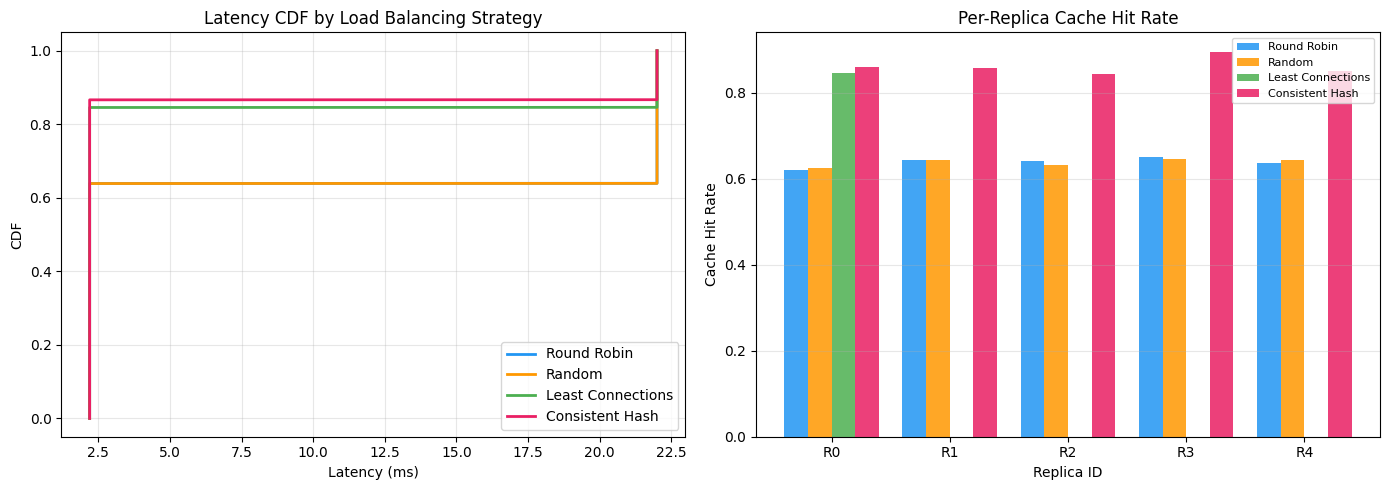

In [8]:
# Visualize load balancing comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_lb = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"]

# Left: Latency CDF comparison
for i, (strategy, result) in enumerate(results_lb.items()):
    sorted_lat = np.sort(result["latencies"])
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, linewidth=2, color=colors_lb[i],
                 label=strategy.replace('_', ' ').title())

axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("CDF")
axes[0].set_title("Latency CDF by Load Balancing Strategy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Cache hit rates per replica
x = np.arange(5)  # 5 replicas
width = 0.2
for i, (strategy, result) in enumerate(results_lb.items()):
    axes[1].bar(x + i * width, result["cache_hit_rates"], width,
                label=strategy.replace('_', ' ').title(), color=colors_lb[i], alpha=0.85)

axes[1].set_xlabel("Replica ID")
axes[1].set_ylabel("Cache Hit Rate")
axes[1].set_title("Per-Replica Cache Hit Rate")
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels([f"R{i}" for i in range(5)])
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Fault Tolerance and Degradation

Production rec systems must handle failures gracefully. Key patterns:

1. **Fallback responses**: If ranking times out, return retrieval results directly (less personalized but still useful)
2. **Circuit breaker**: If a service fails > N% of requests, stop calling it temporarily
3. **Hedged requests**: Send the same request to 2 replicas, take the first response
4. **Graceful degradation**: Under load, skip expensive features or reduce candidate set size

$$
P(\text{success with hedging}) = 1 - P(\text{fail}_1) \cdot P(\text{fail}_2) = 1 - (1-p)^2
$$

where $p$ is the success probability of a single request.

> **🔑 Pro Tip:** Pinterest uses a "quality dial" that adjusts model complexity based on current load. Under normal load, they run the full model; under high load, they switch to a lighter model to maintain latency SLAs.

In [9]:
# Simulate circuit breaker pattern

class CircuitBreaker:
    """Circuit breaker for protecting downstream services."""

    def __init__(self, failure_threshold: int = 5, recovery_timeout: float = 10.0):
        self.failure_threshold = failure_threshold
        self.recovery_timeout = recovery_timeout
        self.failure_count = 0
        self.state = "CLOSED"  # CLOSED (normal), OPEN (blocking), HALF_OPEN (testing)
        self.last_failure_time = 0.0
        self.state_history = []

    def can_execute(self, current_time: float) -> bool:
        if self.state == "CLOSED":
            return True
        elif self.state == "OPEN":
            if current_time - self.last_failure_time > self.recovery_timeout:
                self.state = "HALF_OPEN"
                return True
            return False
        else:  # HALF_OPEN
            return True

    def record_success(self, current_time: float):
        self.failure_count = 0
        if self.state == "HALF_OPEN":
            self.state = "CLOSED"
        self.state_history.append((current_time, self.state))

    def record_failure(self, current_time: float):
        self.failure_count += 1
        self.last_failure_time = current_time
        if self.failure_count >= self.failure_threshold:
            self.state = "OPEN"
        self.state_history.append((current_time, self.state))


# Simulate a service with intermittent failures
np.random.seed(42)
cb = CircuitBreaker(failure_threshold=3, recovery_timeout=5.0)

# Simulate 100 seconds of traffic
times = np.arange(0, 100, 0.1)  # Request every 100ms
request_log = []

for t in times:
    # Inject failure period between t=20 and t=40
    failure_prob = 0.8 if 20 <= t <= 40 else 0.02

    if cb.can_execute(t):
        # Try the service
        if np.random.random() < failure_prob:
            cb.record_failure(t)
            request_log.append({"time": t, "result": "failure", "state": cb.state})
        else:
            cb.record_success(t)
            request_log.append({"time": t, "result": "success", "state": cb.state})
    else:
        # Circuit open - use fallback
        request_log.append({"time": t, "result": "fallback", "state": cb.state})

# Count results
from collections import Counter
result_counts = Counter(r["result"] for r in request_log)
print(f"Total requests: {len(request_log)}")
for result, count in result_counts.items():
    print(f"  {result}: {count} ({count/len(request_log):.1%})")

# Without circuit breaker, all requests during failure period would fail
failure_period_requests = sum(1 for r in request_log if 20 <= r["time"] <= 40)
failure_period_actual_failures = sum(1 for r in request_log
                                      if 20 <= r["time"] <= 40 and r["result"] == "failure")
print(f"\nDuring failure period ({failure_period_requests} requests):")
print(f"  Actual failures (sent to broken service): {failure_period_actual_failures}")
print(f"  Fallbacks (circuit breaker protected): "
      f"{sum(1 for r in request_log if 20 <= r['time'] <= 40 and r['result'] == 'fallback')}")

Total requests: 1000
  success: 781 (78.1%)
  failure: 19 (1.9%)
  fallback: 200 (20.0%)

During failure period (201 requests):
  Actual failures (sent to broken service): 8
  Fallbacks (circuit breaker protected): 192


## 6. Exercise: Multi-Stage Pipeline Simulation

### 🏋️ Exercise 1: Design a Complete Serving Pipeline

Build a multi-stage recommendation serving pipeline with:
1. Feature service with caching
2. Two parallel retrieval sources (ANN and popular items)
3. Ranking service
4. Re-ranking with business rules
5. Latency tracking at each stage
6. Circuit breaker on the ANN retrieval (it's less reliable)

In [10]:
# 🏋️ Exercise 1: Complete serving pipeline

class MultiStageServingPipeline:
    """Complete rec serving pipeline with all production patterns."""

    def __init__(self):
        # TODO: Initialize services, caches, and circuit breaker
        # Hint: Create a feature cache, ANN retrieval with circuit breaker,
        #       popular items retrieval (fallback), ranking service
        self.feature_cache = LRUCache(capacity=5000, ttl_seconds=3600)
        self.ann_circuit_breaker = CircuitBreaker(failure_threshold=3, recovery_timeout=5.0)
        self.latency_log = []
        pass

    def serve(self, user_id: str, current_time: float) -> Dict:
        # TODO: Implement the full pipeline
        # 1. Feature lookup (with cache)
        # 2. Parallel retrieval: ANN (with circuit breaker) + Popular items
        # 3. Merge retrieval results
        # 4. Ranking
        # 5. Re-ranking (apply business rules: diversity, freshness)
        # Return: dict with latency breakdown, num_items, cache_hits
        pass


# TODO: Run 10000 requests and analyze:
# - Latency percentiles (P50, P90, P99)
# - Cache hit rates
# - Circuit breaker activation count
# - Breakdown of latency by stage

### 🏋️ Exercise 2: Latency Budget Optimizer

Given a total latency budget of 150ms, find the optimal allocation across stages that maximizes recommendation quality (modeled as a function of candidates scored).

In [11]:
# 🏋️ Exercise 2: Latency budget optimization

def quality_score(retrieval_budget_ms: float, ranking_budget_ms: float,
                  reranking_budget_ms: float) -> float:
    """
    Model recommendation quality as a function of latency budget per stage.
    More time → more candidates → better quality, but with diminishing returns.
    """
    # TODO: Implement quality model
    # Hint: retrieval quality ~ log(budget) since ANN search scales sublinearly
    #       ranking quality ~ sqrt(budget) since more candidates help
    #       reranking quality ~ budget since business rules need minimum time
    pass


# TODO: Use grid search to find optimal budget allocation
# Total budget: 150ms
# Feature service: fixed 10ms
# Remaining 140ms to allocate between retrieval, ranking, reranking
# Plot the quality surface

### 🏋️ Exercise 3: Hedged Requests Analysis

Implement hedged requests for the ranking service and analyze the latency improvement vs. cost increase.

In [12]:
# 🏋️ Exercise 3: Hedged requests

def simulate_hedged_request(mean_ms: float, std_ms: float,
                            num_hedges: int = 2) -> float:
    """
    Send request to num_hedges replicas, take the fastest response.
    """
    # TODO: Implement hedged request
    # Return the minimum latency across all hedges
    pass


# TODO: Compare latency distributions:
# 1. No hedging (1 request)
# 2. 2-way hedging
# 3. 3-way hedging
# Analyze: What is the latency improvement? What is the cost (extra requests)?
# Plot the CDF comparison

## Summary

Key takeaways from this chapter:

1. **Microservice architecture** decomposes the rec pipeline into independently scalable services (feature, retrieval, ranking, re-ranking)
2. **Latency budgets** must be carefully allocated: retrieval gets the most time, re-ranking the least
3. **Caching** at multiple levels (user embeddings, item embeddings, results) is essential for meeting SLAs
4. **Async serving** with parallel retrieval sources can reduce P50 latency by 30-50%
5. **Consistent hashing** for load balancing maximizes cache hit rates for user-specific data
6. **Circuit breakers** and graceful degradation are critical for production reliability

### References

- Gupta et al., "Architectural Patterns for Machine Learning Serving Systems" (2020, Microsoft)
- Hazelwood et al., "Applied Machine Learning at Facebook: A Datacenter Infrastructure Perspective" (2018, Meta)
- Patterson, "Release It! Design and Deploy Production-Ready Software" (2017)
- Naumov et al., "Deep Learning Recommendation Model for Personalization and Recommendation Systems" (2019, Meta)